In [1]:
import os
os.chdir('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI')

In [2]:
! pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import bnlearn as bn
import time
import matplotlib.pyplot as plt
from itertools import product
#import seaborn as sn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from KbinsDiscretizer import *
#from PlotsFunctions import * 
from DiscreteStructureLearning import *
from Pipeline import *
from Inference import *
from gpytorch_GPR import GPR 

## **Heart Dataset**

In [3]:
# Load the dataset
heartdata = pd.read_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/heart.csv')

### **EDA**

This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

1. age
2. sex
3. chest pain type (4 values)
4. resting blood pressure
5. serum cholestoral in mg/dl
6. fasting blood sugar > 120 mg/dl
7. resting electrocardiographic results (values 0,1,2)
8. maximum heart rate achieved
9. exercise induced angina
10. oldpeak = ST depression induced by exercise relative to rest
11. the slope of the peak exercise ST segment
12. number of major vessels (0-3) colored by flourosopy
13. thal: 0 = normal; 1 = fixed defect; 2 = reversable defect


[Kaggle - Heart Disease Dataset, [https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)]

In [9]:
heartdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [10]:
heartdata.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
heart_cont = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
heart_disc = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

print('Continuous columns: ', heart_cont)
print('Discrete columns: ', heart_disc)

Continuous columns:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Discrete columns:  ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [7]:
# Split the dataset in train and test set
train_heart, test_heart = train_test_split(heartdata, test_size=0.2, random_state=7)

### **Grid Search using 5-Fold Cross-Validation**

We define a grid containing the scoring functions and methodsto explore for structure learning and the metrics to report.

In [4]:
# Define the scoring functions for grid search
scoring = ['aic', 'bic','k2', 'bdeu']
method = ['hc', 'cl']

# Split training set in 5 folds 
hkf = KFold(n_splits=5, shuffle=True, random_state=7)

# List of metrics of interest
metric_keys = [
    "Balanced Accuracy",
    "F1 Score",
    "AUC",
    "Brier Score",
    "KL Divergence",
    "Expected Calibration Loss",
    "Training Time (s)",
    "Inference Time (s)"
]

Then, we run the pipeline as defined in `Pipeline.py`:
- discretization via `KBinsDiscretizer`
- structure learning using `bn.structure_learning`
- parameter learning  using `bn.parameter_learning`
- inference via *Variable Elimination* using `bn.predict`
- evaluation metrics as defined in `Inference.py`

In [13]:
all_results = {}
# Iterate over the scoring functions and method and for each of them perform cross-validation
for s, m in product(scoring, method):

    # Initialize a dictionary to store the values per fold of each metric 
    results_summary = {key: [] for key in metric_keys}
    
    print(f"\n======= SCORING: {s.upper()}, METHOD: {m.upper()} =======")

    n_folds = hkf.get_n_splits()

    for i, (train_idx, test_idx) in enumerate(hkf.split(train_heart), start=1):
        train_df = train_heart.iloc[train_idx]
        test_df = train_heart.iloc[test_idx]

        print(f"\n----- Fold {i}/{n_folds} -----")
        
        # Call BayesianNetworkPipeline using s as the scoring method for structure learning
        metrics = BayesianNetworkPipeline(train_df, test_df, heart_cont, nbins=[4,3,3,3,3], method=m, scoring=s)

        # Extract values for metrics
        for key in metric_keys:

            # Extract numeric value from string
            if key in ["Training Time (s)", "Inference Time (s)"]:            
                value = float(metrics[key].replace(" s", "").strip())

            else: 
                value = float(metrics[key])
            
            # Append the metric 
            results_summary[key].append(value)
    
    # Compute the mean for each metric
    mean_metrics = {key: round(np.mean(values), 4) for key, values in results_summary.items()}
    all_results[(s,m)] = mean_metrics

# Summary of grid search
print("\n==================== FINAL SUMMARY ====================")
for k, metrics in all_results.items():
    print(f"\nScoring: {k[0].upper()}")
    print(f"Method: {k[1].upper()}")
    for key, val in metrics.items():
        print(f"{key}: {val}")


======= SCORING: AIC, METHOD: HC =======

----- Fold 1/5 -----
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x719c0c774710>, 'model_edges': [('age', 'thalach'), ('age', 'oldpeak'), ('age', 'thal'), ('age', 'chol'), ('sex', 'cp'), ('cp', 'exang'), ('cp', 'thalach'), ('trestbps', 'age'), ('trestbps', 'cp'), ('trestbps', 'slope'), ('trestbps', 'fbs'), ('trestbps', 'chol'), ('chol', 'sex'), ('chol', 'exang'), ('fbs', 'thal'), ('fbs', 'slope'), ('fbs', 'age'), ('fbs', 'target'), ('thalach', 'restecg'), ('exang', 'restecg'), ('oldpeak', 'slope'), ('oldpeak', 'cp'), ('oldpeak', 'target'), ('slope', 'thalach'), ('slope', 'restecg'), ('slope', 'chol'), ('ca', 'target'), ('ca', 'age'), ('ca', 'trestbps'), ('ca', 'oldpeak'), ('thal', 'sex'), ('target', 'cp'), ('target', 'thal'), ('target', 'exang'), ('target', 'sex'), ('target', 'chol'), ('target', 'slope')], 'adjmat': target      age    sex     cp  trestbps   chol    fbs  restecg  thalach  \
source                                         

100%|██████████| 129/129 [00:00<00:00, 959.37it/s] 



----- Fold 2/5 -----
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x719c0c8a9690>, 'model_edges': [('age', 'thalach'), ('sex', 'restecg'), ('sex', 'thal'), ('cp', 'exang'), ('cp', 'thalach'), ('cp', 'slope'), ('cp', 'trestbps'), ('trestbps', 'age'), ('trestbps', 'slope'), ('chol', 'ca'), ('chol', 'exang'), ('chol', 'sex'), ('chol', 'target'), ('chol', 'oldpeak'), ('chol', 'cp'), ('fbs', 'ca'), ('fbs', 'cp'), ('fbs', 'sex'), ('fbs', 'thal'), ('thalach', 'restecg'), ('thalach', 'exang'), ('oldpeak', 'slope'), ('oldpeak', 'cp'), ('slope', 'thalach'), ('slope', 'restecg'), ('ca', 'age'), ('ca', 'trestbps'), ('ca', 'target'), ('thal', 'oldpeak'), ('target', 'cp'), ('target', 'oldpeak'), ('target', 'exang'), ('target', 'slope'), ('target', 'thal'), ('target', 'sex')], 'adjmat': target      age    sex     cp  trestbps   chol    fbs  restecg  thalach  \
source                                                                    
age       False  False  False     False  False  False    Fal

100%|██████████| 134/134 [00:00<00:00, 970.05it/s] 



----- Fold 3/5 -----
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x719c0c77a350>, 'model_edges': [('age', 'thalach'), ('age', 'thal'), ('age', 'oldpeak'), ('cp', 'exang'), ('cp', 'thalach'), ('cp', 'oldpeak'), ('cp', 'slope'), ('cp', 'trestbps'), ('trestbps', 'age'), ('trestbps', 'slope'), ('chol', 'sex'), ('chol', 'cp'), ('fbs', 'thal'), ('fbs', 'cp'), ('fbs', 'exang'), ('fbs', 'ca'), ('fbs', 'age'), ('thalach', 'restecg'), ('thalach', 'exang'), ('exang', 'restecg'), ('oldpeak', 'thalach'), ('slope', 'oldpeak'), ('slope', 'restecg'), ('ca', 'age'), ('ca', 'trestbps'), ('ca', 'chol'), ('thal', 'sex'), ('target', 'cp'), ('target', 'thal'), ('target', 'ca'), ('target', 'slope'), ('target', 'exang'), ('target', 'sex'), ('target', 'trestbps'), ('target', 'chol')], 'adjmat': target      age    sex     cp  trestbps   chol    fbs  restecg  thalach  \
source                                                                    
age       False  False  False     False  False  False    Fals

...


----- Fold 5/5 -----


Building tree:   0%|          | 0/91.0 [00:00<?, ?it/s]

model [cl]={'model': <pgmpy.base.DAG.DAG object at 0x719c068e0590>, 'model_edges': [('target', 'cp'), ('target', 'thal'), ('target', 'ca'), ('target', 'slope'), ('cp', 'exang'), ('thal', 'sex'), ('ca', 'age'), ('ca', 'chol'), ('slope', 'oldpeak'), ('slope', 'thalach'), ('age', 'trestbps'), ('thalach', 'restecg'), ('trestbps', 'fbs')], 'adjmat': target    target     cp   thal     ca  slope  exang    sex    age   chol  \
source                                                                     
target     False   True   True   True   True  False  False  False  False   
cp         False  False  False  False  False   True  False  False  False   
thal       False  False  False  False  False  False   True  False  False   
ca         False  False  False  False  False  False  False   True   True   
slope      False  False  False  False  False  False  False  False  False   
exang      False  False  False  False  False  False  False  False  False   
sex        False  False  False  False  False 

100%|██████████| 127/127 [00:00<00:00, 1125.43it/s]


==================== FINAL SUMMARY ====================

Scoring: AIC
Method: HC
Balanced Accuracy: 0.8888
F1 Score: 0.8926
AUC: 0.8888
Brier Score: 0.1122
KL Divergence: 0.2428
Expected Calibration Loss: 0.3124
Training Time (s): 0.6195
Inference Time (s): 0.0414

Scoring: AIC
Method: CL
Balanced Accuracy: 0.8405
F1 Score: 0.8448
AUC: 0.8405
Brier Score: 0.161
KL Divergence: 0.108
Expected Calibration Loss: 0.2286
Training Time (s): 0.16
Inference Time (s): 0.121

Scoring: BIC
Method: HC
Balanced Accuracy: 0.8452
F1 Score: 0.8485
AUC: 0.8452
Brier Score: 0.1561
KL Divergence: 0.1861
Expected Calibration Loss: 0.2868
Training Time (s): 0.4342
Inference Time (s): 0.1325

Scoring: BIC
Method: CL
Balanced Accuracy: 0.8405
F1 Score: 0.8448
AUC: 0.8405
Brier Score: 0.161
KL Divergence: 0.108
Expected Calibration Loss: 0.2286
Training Time (s): 0.0601
Inference Time (s): 0.1207

Scoring: K2
Method: HC
Balanced Accuracy: 0.9471
F1 Score: 0.9465
AUC: 0.9471
Brier Score: 0.0537
KL Divergence: 

### **Pre-Processing**

Now, we retrain the model using the entire training set and the same pipeline using the best performing scoring function ($k2$) and method (*hillclimb*) and we test on the unseen test data. 

In [23]:
# Fit the discretizer on the training set
discretizer_heart, train_dheart = discretize_fit(train_heart, heart_cont, [4,3,3,3,3], transform=True)

# Trasnsform the test set
test_dheart = discretize_transform(test_heart, heart_cont, discretizer_heart)

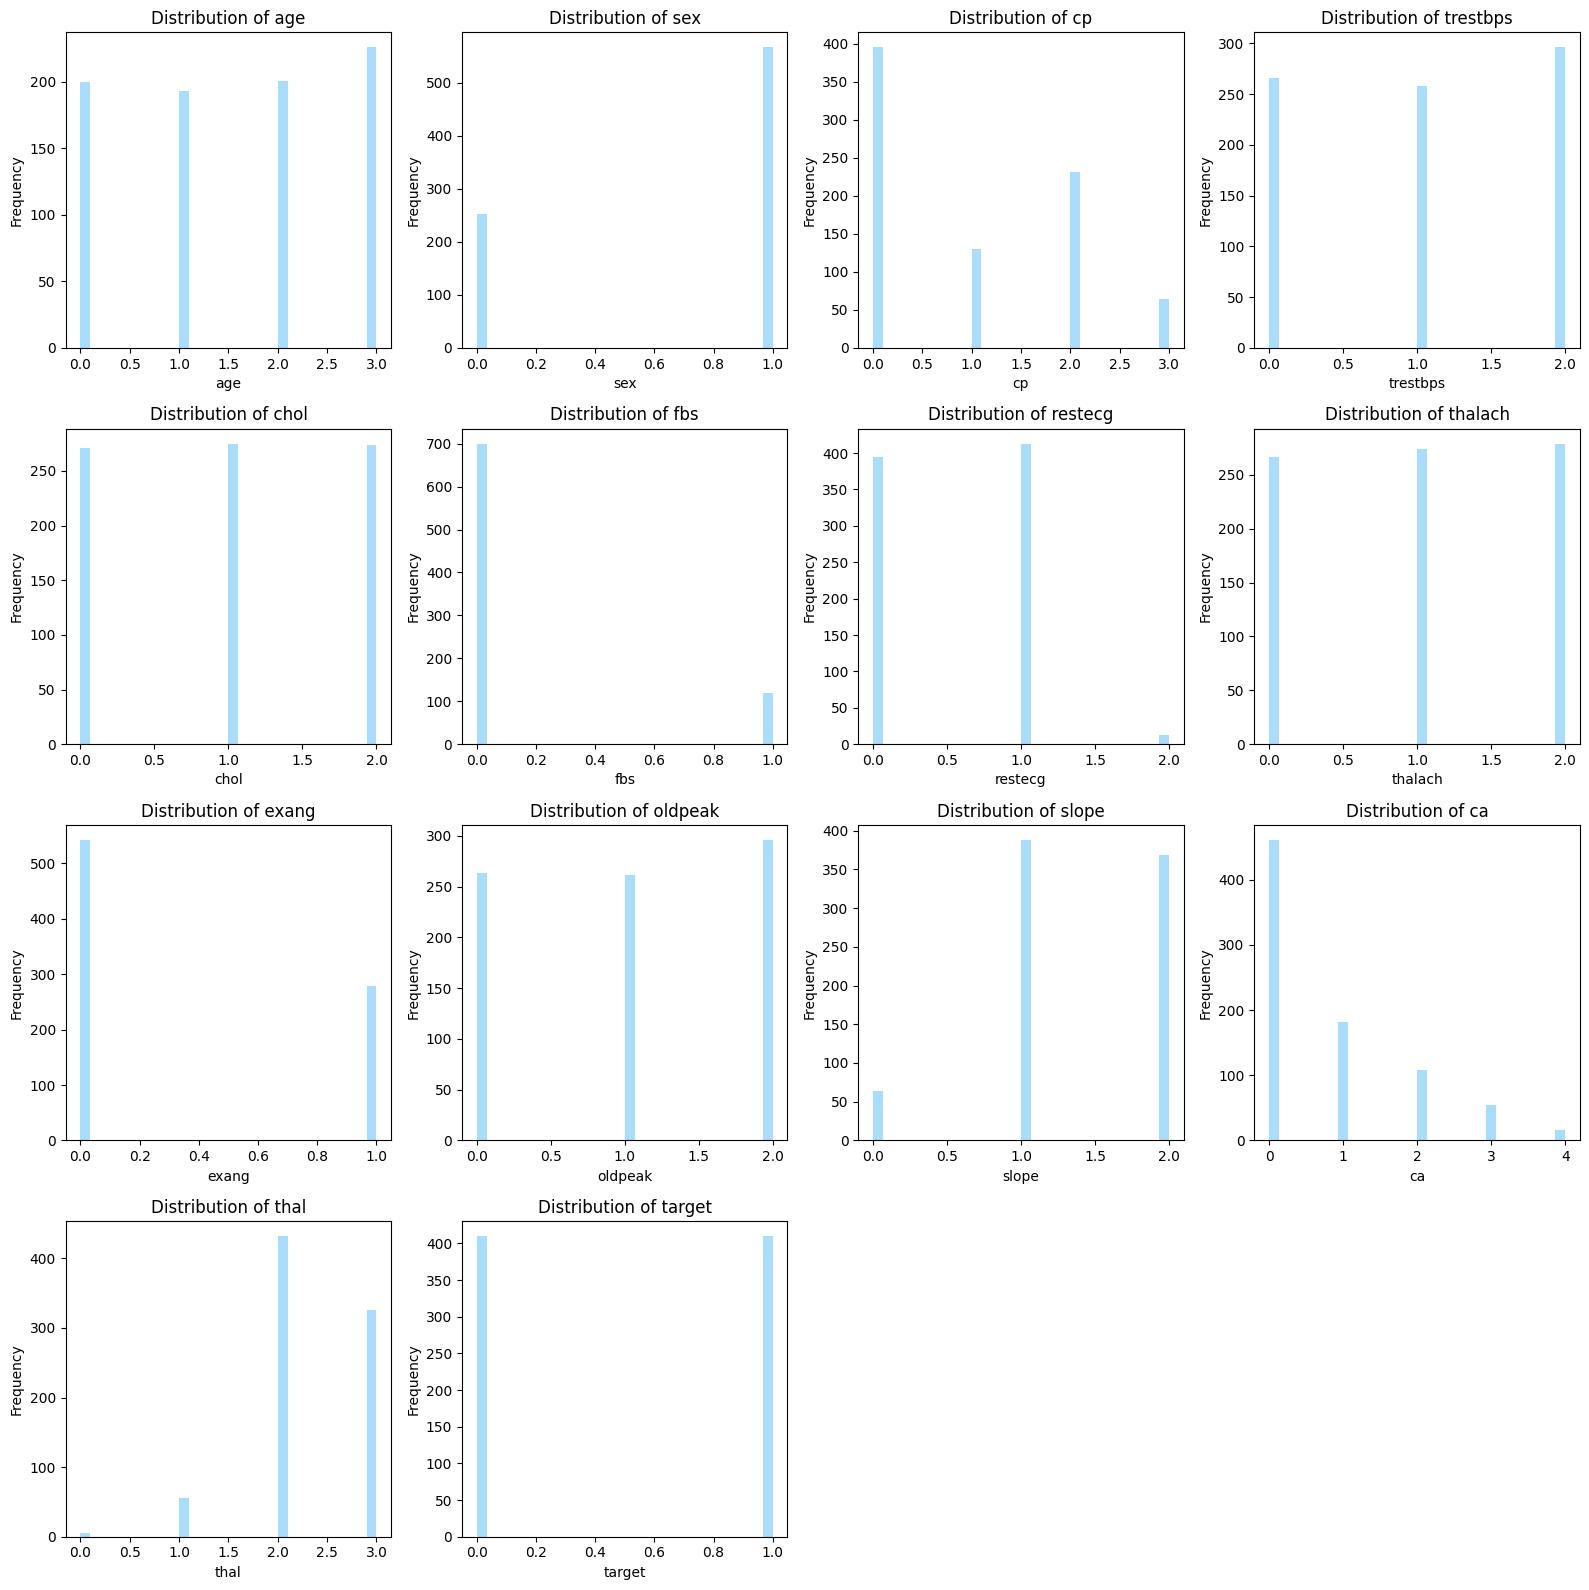

In [11]:
# Visualize the discretized variables in the train set:
plot_distributions(train_dheart, train_dheart.columns)


### **Structure and Parameter Learning**

model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x714e5dcf4650>, 'model_edges': [('age', 'ca'), ('sex', 'age'), ('sex', 'thalach'), ('sex', 'oldpeak'), ('sex', 'trestbps'), ('sex', 'ca'), ('sex', 'slope'), ('cp', 'target'), ('cp', 'exang'), ('cp', 'age'), ('cp', 'thalach'), ('cp', 'oldpeak'), ('cp', 'trestbps'), ('cp', 'slope'), ('cp', 'ca'), ('cp', 'fbs'), ('trestbps', 'age'), ('trestbps', 'ca'), ('chol', 'age'), ('chol', 'thalach'), ('chol', 'oldpeak'), ('chol', 'target'), ('chol', 'trestbps'), ('chol', 'sex'), ('chol', 'slope'), ('chol', 'ca'), ('chol', 'exang'), ('fbs', 'age'), ('fbs', 'thalach'), ('fbs', 'oldpeak'), ('fbs', 'trestbps'), ('fbs', 'slope'), ('fbs', 'ca'), ('restecg', 'age'), ('restecg', 'thalach'), ('restecg', 'oldpeak'), ('restecg', 'target'), ('restecg', 'trestbps'), ('restecg', 'chol'), ('restecg', 'sex'), ('restecg', 'slope'), ('restecg', 'ca'), ('restecg', 'cp'), ('restecg', 'fbs'), ('thalach', 'age'), ('thalach', 'oldpeak'), ('thalach', 'trestbps'), ('thalac

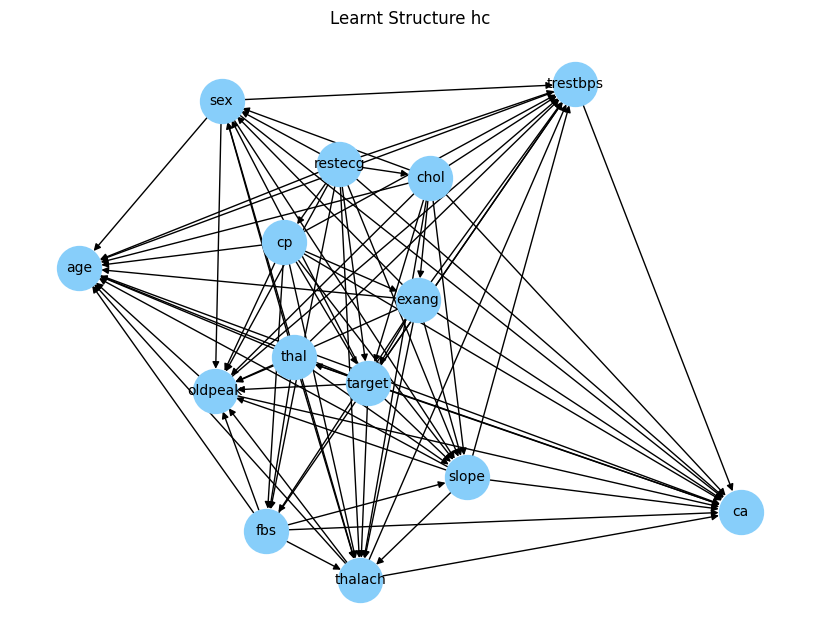

In [24]:
heart_start = time.time()

# Learn Structure
heart_structure = structure_learning(train_dheart, "hc", "k2", 2000000, dataset_name="Heart")

# Learn parameters
param_heart_structure = bn.parameter_learning.fit(heart_structure, train_dheart)

heart_train_time = time.time() - heart_start 

In [8]:
generate_config(heart_structure, name='heart_config', filename=None)

Generated configuration file at: /workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/config/heart_config.txt


### **Inference**

In [25]:
# Call infer_and_evaluate to obtain metrics and predictions
h_metrics, y_pred_heart, y_probs_heart = infer_and_evaluate(test_dheart, param_heart_structure, heart_train_time, model_name='BayesianNetwork', labels = True)
h_metrics

[bnlearn]> Remaining columns for inference: 13


100%|██████████| 157/157 [00:01<00:00, 96.99it/s]


{'Model': 'BayesianNetwork',
 'Balanced Accuracy': 0.9659,
 'F1 Score': 0.9697,
 'AUC': 0.9659,
 'Brier Score': 0.0341,
 'KL Divergence': 1.1932,
 'Expected Calibration Loss': 0.4397,
 'Training Time (s)': '64.0887 s',
 'Inference Time (s)': '1.6306 s'}

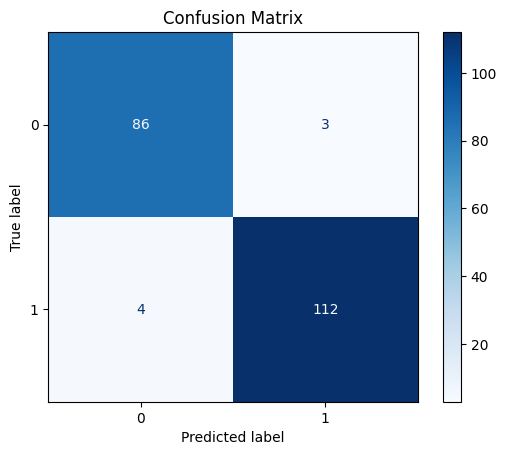

In [26]:
# Display confusion matrix
y_true_heart = test_dheart["target"]
cm = confusion_matrix(y_true_heart, y_pred_heart)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

As we can see from the metrics and the confusion matrix, the model overall performance is robust.

### **Naive Bayes**

In [19]:
BayesianNetworkPipeline(train_heart, test_heart, heart_cont, nbins=[4,3,3,3,3], naive=True)

[bnlearn]> Auto generate placeholders for the CPTs.
[bnlearn] >CPT for target:
+-----------+-------------+-----+-------------+-------------+
| age       | age(0)      | ... | age(1)      | age(1)      |
+-----------+-------------+-----+-------------+-------------+
| sex       | sex(0)      | ... | sex(1)      | sex(1)      |
+-----------+-------------+-----+-------------+-------------+
| cp        | cp(0)       | ... | cp(1)       | cp(1)       |
+-----------+-------------+-----+-------------+-------------+
| trestbps  | trestbps(0) | ... | trestbps(1) | trestbps(1) |
+-----------+-------------+-----+-------------+-------------+
| chol      | chol(0)     | ... | chol(1)     | chol(1)     |
+-----------+-------------+-----+-------------+-------------+
| fbs       | fbs(0)      | ... | fbs(1)      | fbs(1)      |
+-----------+-------------+-----+-------------+-------------+
| restecg   | restecg(0)  | ... | restecg(1)  | restecg(1)  |
+-----------+-------------+-----+-------------+------

[bnlearn]> Remaining columns for inference: 13


100%|██████████| 157/157 [00:03<00:00, 50.90it/s]


{'Model': 'NaiveBayes',
 'Balanced Accuracy': 0.9698,
 'F1 Score': 0.9689,
 'AUC': 0.9698,
 'Brier Score': 0.0341,
 'KL Divergence': 0.9393,
 'Expected Calibration Loss': 0.4291,
 'Training Time (s)': '24.8491 s',
 'Inference Time (s)': '3.0944 s'}

### **Gaussian Process**

In [8]:
train_heart.to_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/heart_train.csv', index=False, encoding="utf-8")
test_heart.to_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/heart_test.csv', index=False, encoding="utf-8")

#### **Grid Search using 5-Fold Cross-Validation**

In [20]:
train_file = "/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/heart_train.csv"
test_file = "/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/heart_test.csv"

NUM_INDUCING_POINTS_OPTIONS = [50, 100, 300]
GP_METHODS = ["GPR_VarSparse", "GPR_Sparse"]

In [10]:
all_results = {}

# Iterate over the sthe grid and for each of them perform cross-validation
for NUM_INDUCING_POINTS, GP_METHOD2EMPLOY in product(
    NUM_INDUCING_POINTS_OPTIONS,
    GP_METHODS
):
    print(f"\n======= INDUCING={NUM_INDUCING_POINTS}, METHOD={GP_METHOD2EMPLOY} =======")

    # Initialize a dictionary to store the values per fold of each metric
    results_summary = {key: [] for key in metric_keys}
    n_folds = hkf.get_n_splits()

    for i, (train_idx, test_idx) in enumerate(hkf.split(train_heart), start=1):
        print(f"\n----- Fold {i}/{n_folds} -----")

        train_df = train_heart.iloc[train_idx]
        test_df = train_heart.iloc[test_idx]

        # Save temporarily the folds in CSV 
        train_path = f"/tmp/fold_{i}_train.csv"
        test_path = f"/tmp/fold_{i}_test.csv"
        train_df.to_csv(train_path, index=False)
        test_df.to_csv(test_path, index=False)

        # Run model
        gpr_model = GPR(
            train_path,
            test_path,
            STANDARDISE_DATA=True,
            GP_METHOD2EMPLOY=GP_METHOD2EMPLOY,
            NUM_INDUCING_POINTS=NUM_INDUCING_POINTS
        )

        # Extract values for metrics
        metrics = gpr_model.results

        for key in metric_keys:
            val = metrics[key]
            if isinstance(val, str) and val.endswith(" s"):
                val = float(val.replace(" s", "").strip())
            else:
                val = float(val)
            results_summary[key].append(val)

    # Compute the mean for each metric
    mean_metrics = {key: round(np.mean(values), 4) for key, values in results_summary.items()}
    all_results[(NUM_INDUCING_POINTS, GP_METHOD2EMPLOY)] = mean_metrics

# Summary of grid search
print("\n==================== FINAL SUMMARY ====================")
for combo, metrics in all_results.items():
    n, m = combo
    print(f"\nINDUCING: {n}, METHOD: {m}")
    for key, val in metrics.items():
        print(f"{key}: {val}")


======= INDUCING=50, METHOD=GPR_VarSparse =======

----- Fold 1/5 -----
LOADING and PROCESSING data...
LOADING and PROCESSING data...
STANDARDISE_DATA=True
656 training instances
164 test instances
50 inducing points
Using device: cuda

TRAINING Gaussian Process model...
Loss function: Evidence Lower Bound (ELBO)
Iteration 1, improved=True: Loss=1.5930781364440918
Iteration 11, improved=True: Loss=1.22317636013031
Iteration 21, improved=True: Loss=1.0944243669509888
Iteration 31, improved=True: Loss=0.9007664322853088
Iteration 41, improved=True: Loss=0.6817923188209534
Iteration 51, improved=True: Loss=0.4832952916622162
Iteration 61, improved=True: Loss=0.3599628210067749
Iteration 71, improved=True: Loss=0.32598063349723816
Iteration 81, improved=True: Loss=0.3256707489490509
Iteration 91, improved=True: Loss=0.32222482562065125
Iteration 101, improved=True: Loss=0.3197174072265625
Iteration 111, improved=True: Loss=0.3185822069644928
Iteration 121, improved=True: Loss=0.3179228603

considerations: 


#### **Final Train and Test on Held-out Test Set**

In [23]:
# Optimal Configuration
GP_METHOD2EMPLOY = "GPR_Sparse"
NUM_INDUCING_POINTS = 300

# Refit and Test
gpr_model = GPR(
    train_file,
    test_file,
    STANDARDISE_DATA=True,
    GP_METHOD2EMPLOY=GP_METHOD2EMPLOY,
    NUM_INDUCING_POINTS=NUM_INDUCING_POINTS
)

# Extract results
results = gpr_model.results

LOADING and PROCESSING data...
LOADING and PROCESSING data...
STANDARDISE_DATA=True
820 training instances
205 test instances
300 inducing points
Using device: cuda

TRAINING Gaussian Process model...
Loss function: Marginal Log Likelihood (MLL)
Iteration 1, improved=True: Loss=1.0576759576797485
Iteration 11, improved=True: Loss=0.6518975496292114
Iteration 21, improved=True: Loss=0.2699829936027527
Iteration 31, improved=True: Loss=0.036746636033058167
Iteration 41, improved=True: Loss=-0.2977437376976013
Iteration 51, improved=True: Loss=-0.6028888821601868
Iteration 61, improved=True: Loss=-0.9209262132644653
Iteration 71, improved=True: Loss=-1.1631591320037842
Iteration 81, improved=True: Loss=-1.3297001123428345
Iteration 91, improved=True: Loss=-1.4482290744781494
Iteration 101, improved=True: Loss=-1.6023411750793457
Iteration 111, improved=True: Loss=-1.6034427881240845
Iteration 121, improved=False: Loss=-1.573051929473877
Iteration 131, improved=True: Loss=-1.73535501956939


Final Test Results:

Model: GPR
Balanced Accuracy: 1.0
F1 Score: 1.0
AUC: 1.0
Brier Score: 0.0049
KL Divergence: 0.0172
Expected Calibration Loss: 0.442
Training Time (s): 1.7015 s
Inference Time (s): -0.0404 s


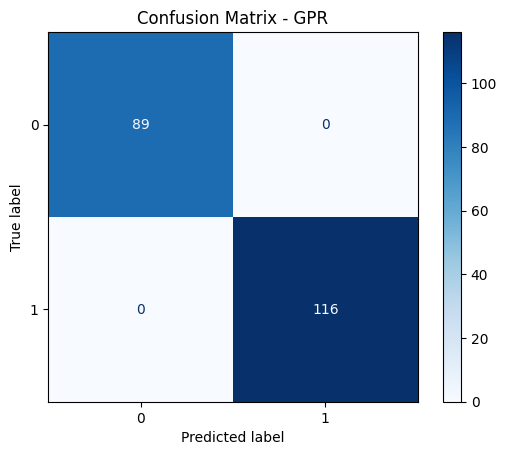

In [24]:
# Extract metrics
results_clean = {k: v for k, v in results.items() if k not in ["Y_pred", "Y_prob"]}

print("\nFinal Test Results:\n")
for k, v in results_clean.items():
    print(f"{k}: {v}")

# Confusion Matrix
test_df = pd.read_csv(test_file)
y_true = test_df["target"]
y_pred = np.array(results["Y_pred"])

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {results['Model']}")
plt.show()

## **Fraud Dataset**

In [11]:
# Load the dataset
frauddata = pd.read_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/synthetic_fraud_dataset.csv')

### **EDA**

This dataset is designed to help data scientists and machine learning enthusiasts develop robust fraud detection models. It contains realistic synthetic transaction data, including user information, transaction types, risk scores, and more, making it ideal for binary classification tasks with models like XGBoost and LightGBM.

1. Transaction_ID
2. User_ID
3. Transaction_Amount
4. Transaction_Type
5. Timestamp
6. Account_Balance
7. Device_Type
8. Location
9. Merchant_Category
10. IP_Address_Flag
11. Previous_Fraudulent_Activity
12. Daily_Transaction_Count
13. Avg_Transaction_Amount_7d
14. Failed_Transaction_Count_7d
15. Card_Type
16. Card_Age
17. Transaction_Distance
18. Authentication_Method
19. Risk_Score
20. Is_Weekend
21. Fraud_Label

[Kaggle - Fraud Detection Transactions Dataset, https://www.kaggle.com/datasets/samayashar/fraud-detection-transactions-dataset]

In [20]:
frauddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [21]:
frauddata.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [12]:
# Rename target column
frauddata.rename(columns={'Fraud_Label':'target'}, inplace=True)

# Drop ID columns
frauddata = frauddata.drop(columns=['Transaction_ID', 'User_ID', 'Timestamp'])
frauddata

,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,target
0,39.79,POS,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,31.28,POS,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,45.05,Online,76960.11,Mobile,Tokyo,Clothing,0,0,2,389.00,3,Amex,98,1537.54,PIN,0.1493,1,0
49996,126.15,POS,28791.75,Mobile,Tokyo,Clothing,0,0,13,434.95,4,Visa,93,2555.72,Biometric,0.3653,0,1
49997,72.02,Online,29916.41,Laptop,Mumbai,Clothing,0,1,1,369.15,2,Visa,114,4686.59,Biometric,0.5195,0,0
49998,64.89,Bank Transfer,67895.67,Mobile,Tokyo,Electronics,0,0,13,242.29,4,Discover,72,4886.92,Biometric,0.7063,0,1


In [13]:
# Identify continuous and discrete columns
fraud_cont = ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score']
fraud_disc = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Failed_Transaction_Count_7d', 
              'Card_Type', 'Authentication_Method', 'Is_Weekend', 'Fraud_Label']

# Identify categorical variables 
fraud_cat = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']

print('Continuous columns: ', fraud_cont)
print('Discrete columns: ', fraud_disc)

Continuous columns:  ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score']
Discrete columns:  ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Failed_Transaction_Count_7d', 'Card_Type', 'Authentication_Method', 'Is_Weekend', 'Fraud_Label']


In [14]:
# Encode the categorical variables
fraud_df_encoded = frauddata.copy()
for col in fraud_cat:
    le = LabelEncoder()
    fraud_df_encoded[col] = le.fit_transform(frauddata[col])

In [15]:
# Split the dataset into training and testing sets
train_fraud, test_fraud = train_test_split(fraud_df_encoded, test_size=0.2, random_state=7)

### **Grid Search using 5-Fold Cross-Validation**

In [16]:
# Split training set in 5 folds 
fkf = KFold(n_splits=5, shuffle=True, random_state=7)

Then, we run the pipeline as defined in `Pipeline.py`

In [46]:
all_results = {}
# Iterate over the scoring functions and method and for each of them perform cross-validation
for s, m in product(scoring, method): 

    # Initialize a dictionary to store the values per fold of each metric 
    results_summary = {key: [] for key in metric_keys}
    
    print(f"\n======= SCORING: {s.upper()}, METHOD: {m.upper()} =======")

    n_folds = fkf.get_n_splits()

    for i, (train_idx, test_idx) in enumerate(fkf.split(train_fraud), start=1):
        train_df = train_fraud.iloc[train_idx]
        test_df = train_fraud.iloc[test_idx]

        print(f"\n----- Fold {i}/{n_folds} -----")
        
        # Call BayesianNetworkPipeline using s as the scoring method for structure learning
        metrics = BayesianNetworkPipeline(train_df, test_df, fraud_cont, nbins=[3,3,3,3,3,3,3], method=m, scoring=s)

        # Extract values for metrics
        for key in metric_keys:

            # Extract numeric value from string
            if key in ["Training Time (s)", "Inference Time (s)"]:            
                value = float(metrics[key].replace(" s", "").strip())

            else: 
                value = float(metrics[key])
            
            # Append the metric 
            results_summary[key].append(value)
    
    # Compute the mean for each metric
    mean_metrics = {key: round(np.mean(values), 4) for key, values in results_summary.items()}
    all_results[(s,m)] = mean_metrics

# Summary of grid search
print("\n==================== FINAL SUMMARY ====================")
for k, metrics in all_results.items():
    print(f"\nScoring: {k[0].upper()}")
    print(f"Method: {k[1].upper()}")
    for key, val in metrics.items():
        print(f"{key}: {val}")


======= SCORING: AIC, METHOD: HC =======

----- Fold 1/5 -----
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x714e5689da90>, 'model_edges': [('Device_Type', 'IP_Address_Flag'), ('Device_Type', 'Card_Age'), ('Device_Type', 'Avg_Transaction_Amount_7d'), ('Location', 'IP_Address_Flag'), ('IP_Address_Flag', 'Transaction_Amount'), ('IP_Address_Flag', 'Avg_Transaction_Amount_7d'), ('Avg_Transaction_Amount_7d', 'Risk_Score'), ('Failed_Transaction_Count_7d', 'target'), ('Risk_Score', 'target'), ('Risk_Score', 'Transaction_Type'), ('Is_Weekend', 'Location')], 'adjmat': target                        Transaction_Amount  Transaction_Type  \
source                                                               
Transaction_Amount                         False             False   
Transaction_Type                           False             False   
Account_Balance                            False             False   
Device_Type                                False             False   
Locati

100%|██████████| 7348/7348 [-1:59:58<00:00, -2715.05it/s]



----- Fold 2/5 -----
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x714e568d6890>, 'model_edges': [('Account_Balance', 'Risk_Score'), ('Device_Type', 'Card_Age'), ('Location', 'IP_Address_Flag'), ('Location', 'Is_Weekend'), ('IP_Address_Flag', 'Transaction_Amount'), ('IP_Address_Flag', 'Account_Balance'), ('Avg_Transaction_Amount_7d', 'Authentication_Method'), ('Card_Type', 'Device_Type'), ('Card_Age', 'IP_Address_Flag'), ('Card_Age', 'Account_Balance'), ('Transaction_Distance', 'Location'), ('Transaction_Distance', 'Avg_Transaction_Amount_7d'), ('Transaction_Distance', 'Is_Weekend'), ('Authentication_Method', 'Daily_Transaction_Count'), ('Risk_Score', 'Failed_Transaction_Count_7d'), ('Risk_Score', 'target'), ('Risk_Score', 'Transaction_Type'), ('target', 'Failed_Transaction_Count_7d')], 'adjmat': target                        Transaction_Amount  Transaction_Type  \
source                                                               
Transaction_Amount                         F

100%|██████████| 7998/7998 [00:07<00:00, 1129.89it/s]



----- Fold 3/5 -----
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x714e5c29bd50>, 'model_edges': [('Account_Balance', 'Card_Age'), ('Device_Type', 'IP_Address_Flag'), ('Location', 'IP_Address_Flag'), ('IP_Address_Flag', 'Transaction_Amount'), ('IP_Address_Flag', 'Card_Type'), ('Previous_Fraudulent_Activity', 'Transaction_Type'), ('Previous_Fraudulent_Activity', 'Authentication_Method'), ('Daily_Transaction_Count', 'Failed_Transaction_Count_7d'), ('Failed_Transaction_Count_7d', 'target'), ('Card_Type', 'Is_Weekend'), ('Transaction_Distance', 'Avg_Transaction_Amount_7d'), ('Authentication_Method', 'Device_Type'), ('Risk_Score', 'target'), ('Is_Weekend', 'Transaction_Distance'), ('Is_Weekend', 'Transaction_Type'), ('target', 'Previous_Fraudulent_Activity'), ('target', 'Account_Balance')], 'adjmat': target                        Transaction_Amount  Transaction_Type  \
source                                                               
Transaction_Amount                         Fa

...


----- Fold 5/5 -----


Building tree:   0%|          | 0/153.0 [00:00<?, ?it/s]

model [cl]={'model': <pgmpy.base.DAG.DAG object at 0x714e568f7d90>, 'model_edges': [('target', 'Failed_Transaction_Count_7d'), ('target', 'Risk_Score'), ('Failed_Transaction_Count_7d', 'Card_Type'), ('Failed_Transaction_Count_7d', 'Transaction_Type'), ('Failed_Transaction_Count_7d', 'Card_Age'), ('Failed_Transaction_Count_7d', 'Authentication_Method'), ('Failed_Transaction_Count_7d', 'Transaction_Distance'), ('Card_Type', 'Merchant_Category'), ('Card_Type', 'Device_Type'), ('Card_Type', 'Daily_Transaction_Count'), ('Authentication_Method', 'Location'), ('Authentication_Method', 'Avg_Transaction_Amount_7d'), ('Authentication_Method', 'Account_Balance'), ('Location', 'Transaction_Amount'), ('Location', 'IP_Address_Flag'), ('Location', 'Previous_Fraudulent_Activity'), ('Location', 'Is_Weekend')], 'adjmat': target                        target  Failed_Transaction_Count_7d  Risk_Score  \
source                                                                          
target                 

100%|██████████| 8000/8000 [00:07<00:00, 1002.72it/s]


==================== FINAL SUMMARY ====================

Scoring: AIC
Method: HC
Balanced Accuracy: 0.8099
F1 Score: 0.7651
AUC: 0.8099
Brier Score: 0.1225
KL Divergence: 0.783
Expected Calibration Loss: 0.5445
Training Time (s): 1.9295
Inference Time (s): 7.0249

Scoring: AIC
Method: CL
Balanced Accuracy: 0.8099
F1 Score: 0.7652
AUC: 0.8099
Brier Score: 0.1224
KL Divergence: 0.7255
Expected Calibration Loss: 0.5398
Training Time (s): 0.6226
Inference Time (s): 8.1355

Scoring: BIC
Method: HC
Balanced Accuracy: 0.8099
F1 Score: 0.7652
AUC: 0.8099
Brier Score: 0.1224
KL Divergence: 0.783
Expected Calibration Loss: 0.5445
Training Time (s): 0.5464
Inference Time (s): 0.012

Scoring: BIC
Method: CL
Balanced Accuracy: 0.8099
F1 Score: 0.7652
AUC: 0.8099
Brier Score: 0.1224
KL Divergence: 0.7255
Expected Calibration Loss: 0.5398
Training Time (s): 0.6173
Inference Time (s): 8.0313

Scoring: K2
Method: HC
Balanced Accuracy: 0.8099
F1 Score: 0.7652
AUC: 0.8099
Brier Score: 0.1224
KL Divergen

### **Pre-Processing**

Now, we retrain the model using the entire training set and the same pipeline using the best performing scoring function ($bic$) and method (*Chow-liu*) and we test on the unseen test data. 

In [41]:
# Fit the discretizer on the training set
discretizer_fraud, train_dfraud = discretize_fit(train_fraud, fraud_cont, [3,3,3,3,3,3,3], transform=True)

# Trasnsform the test set
test_dfraud = discretize_transform(test_fraud, fraud_cont, discretizer_fraud)

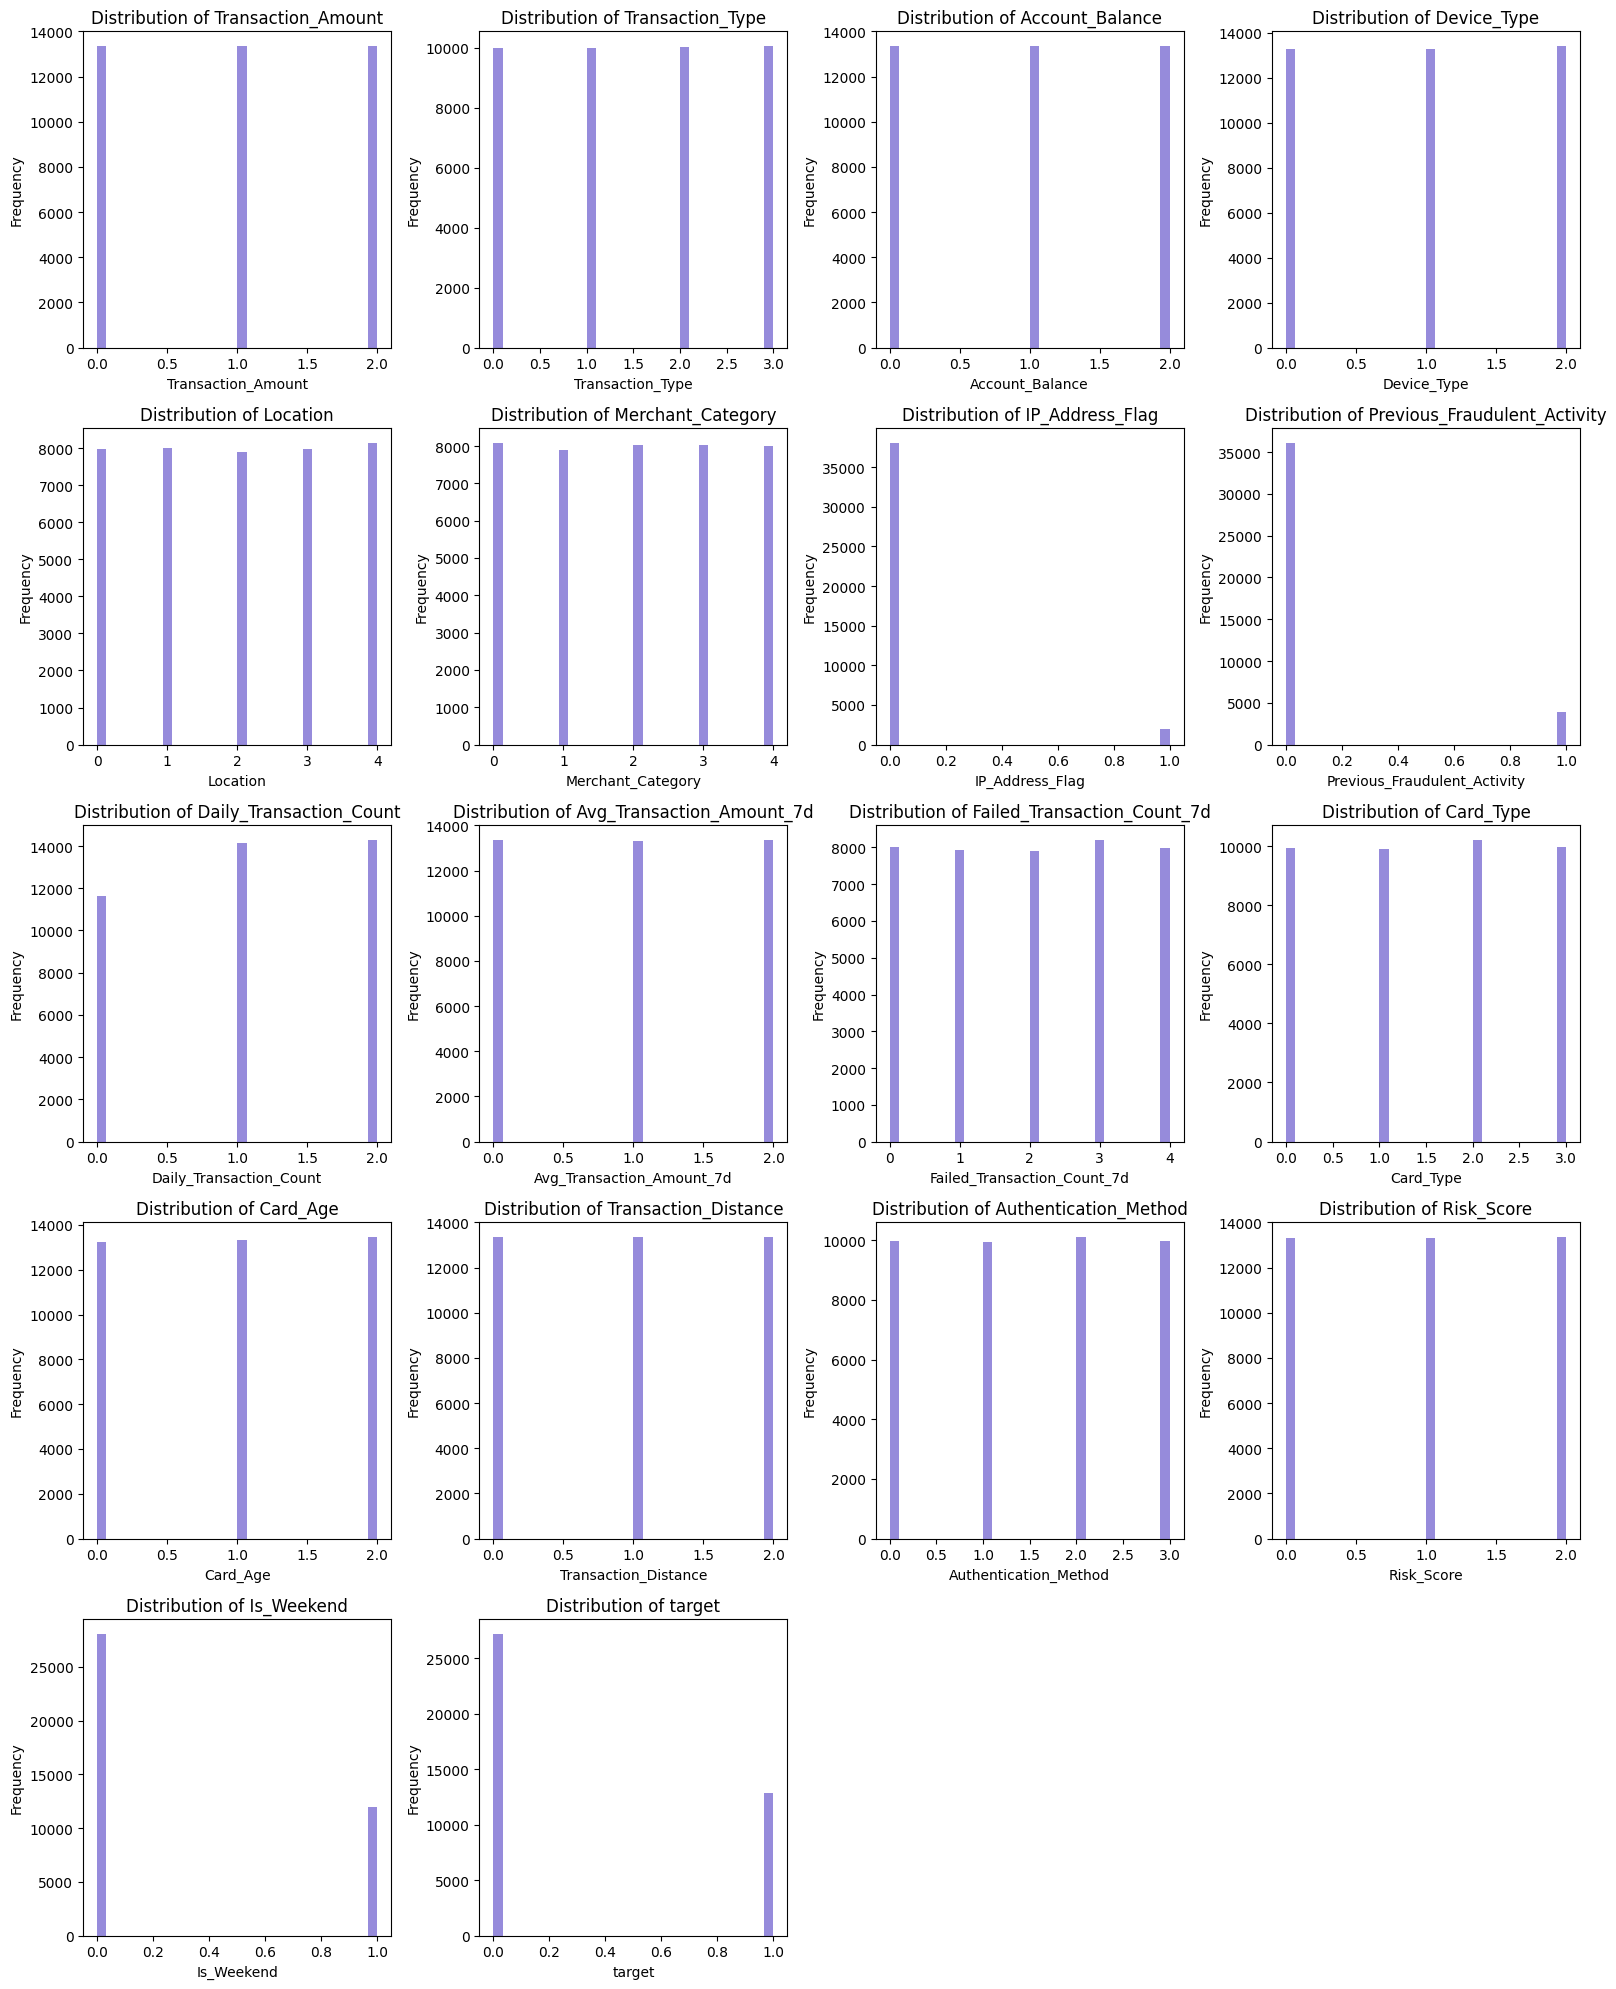

In [48]:
# Visualize the discretized variables in the train set:
plot_distributions(train_dfraud, train_dfraud.columns, color='slateblue')

### **Structure and Parameter Learning**

Building tree:   0%|          | 0/153.0 [00:00<?, ?it/s]

model [cl]={'model': <pgmpy.base.DAG.DAG object at 0x714e56668e10>, 'model_edges': [('target', 'Failed_Transaction_Count_7d'), ('target', 'Risk_Score'), ('Failed_Transaction_Count_7d', 'Card_Type'), ('Failed_Transaction_Count_7d', 'Card_Age'), ('Failed_Transaction_Count_7d', 'Daily_Transaction_Count'), ('Failed_Transaction_Count_7d', 'Transaction_Type'), ('Card_Type', 'Merchant_Category'), ('Card_Type', 'Device_Type'), ('Card_Type', 'Is_Weekend'), ('Card_Age', 'Account_Balance'), ('Merchant_Category', 'Location'), ('Merchant_Category', 'Avg_Transaction_Amount_7d'), ('Location', 'IP_Address_Flag'), ('Location', 'Authentication_Method'), ('Location', 'Transaction_Distance'), ('Location', 'Transaction_Amount'), ('Location', 'Previous_Fraudulent_Activity')], 'adjmat': target                        target  Failed_Transaction_Count_7d  Risk_Score  \
source                                                                          
target                         False                         Tr

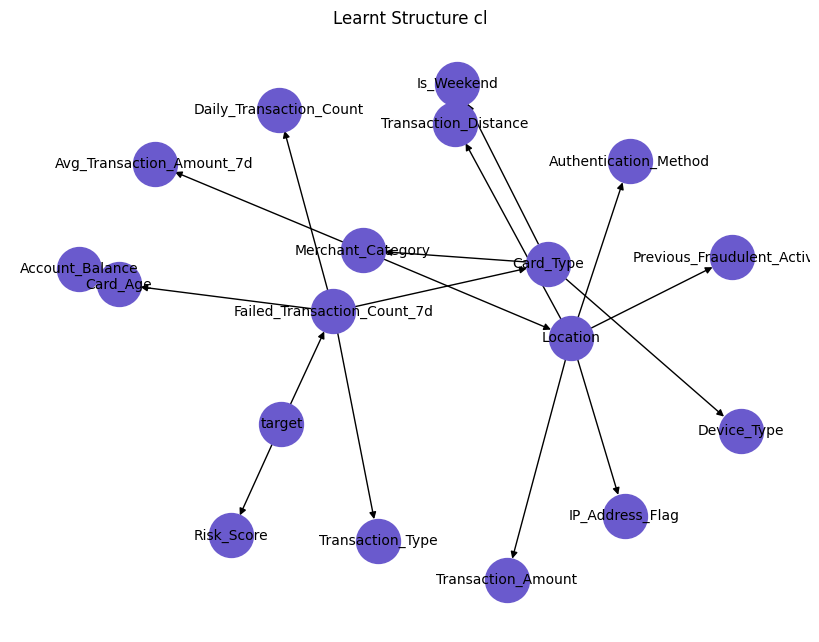

In [49]:
fraud_start = time.time()

# Learn Structure
fraud_structure = structure_learning(train_dfraud, "cl", "bic", 2000000, dataset_name="Fraud", color = "slateblue")

# Learn parameters
param_fraud_structure = bn.parameter_learning.fit(fraud_structure, train_dfraud)

fraud_train_time = time.time() - fraud_start 

### **Inference**

In [50]:
# Call infer_and_evaluate to obtain metrics and predictions
f_metrics, y_pred_fraud, y_probs_fraud = infer_and_evaluate(test_dfraud, param_fraud_structure, fraud_train_time, model_name='BayesianNetwork', labels = True)
f_metrics

[bnlearn]> Remaining columns for inference: 17


100%|██████████| 9998/9998 [00:09<00:00, 1003.96it/s]


{'Model': 'BayesianNetwork',
 'Balanced Accuracy': 0.8093,
 'F1 Score': 0.7644,
 'AUC': 0.8093,
 'Brier Score': 0.1218,
 'KL Divergence': 0.7345,
 'Expected Calibration Loss': 0.5415,
 'Training Time (s)': '4.9454 s',
 'Inference Time (s)': '10.3472 s'}

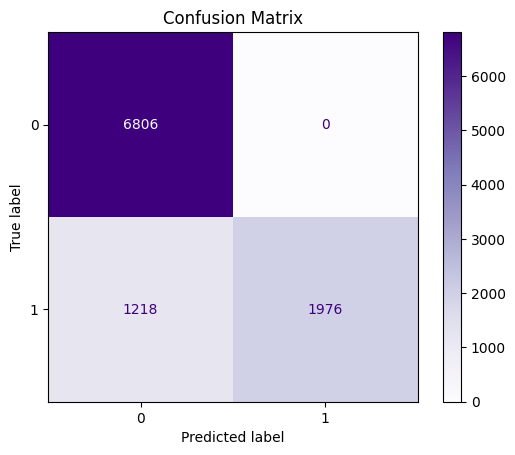

In [51]:
# Display confusion matrix
y_true_fraud = test_dfraud["target"]
cm = confusion_matrix(y_true_fraud, y_pred_fraud)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1]) 
disp.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix")
plt.show()

As we can see from the metrics and the confusion matrix, the precision for class 1 is 1.0 as there are no false positives, conversely the recall is rather low.

For class 0, the recall is 1.0 as all 0 instances are correctly classified, however, the precision is lower.

This suggests that the model tends to predict class 0, often failing to correctly identify fraud.

### **Gaussian Process**

In [17]:
train_fraud.to_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/fraud_train.csv', index=False, encoding="utf-8")
test_fraud.to_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/fraud_test.csv', index=False, encoding="utf-8")

#### **Grid Search using 5-Fold Cross-Validation**

In [27]:
train_file = "/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/fraud_train.csv"
test_file = "/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/fraud_test.csv"

NUM_INDUCING_POINTS_OPTIONS = [50, 100, 300]
GP_METHODS = ["GPR_VarSparse", "GPR_Sparse"]

In [19]:
all_results = {}

# Iterate over the sthe grid and for each of them perform cross-validation
for NUM_INDUCING_POINTS, GP_METHOD2EMPLOY in product(
    NUM_INDUCING_POINTS_OPTIONS,
    GP_METHODS
):
    print(f"\n======= INDUCING={NUM_INDUCING_POINTS}, METHOD={GP_METHOD2EMPLOY} =======")

    # Initialize a dictionary to store the values per fold of each metric
    results_summary = {key: [] for key in metric_keys}
    n_folds = hkf.get_n_splits()

    for i, (train_idx, test_idx) in enumerate(fkf.split(train_fraud), start=1):
        print(f"\n----- Fold {i}/{n_folds} -----")

        train_df = train_fraud.iloc[train_idx]
        test_df = train_fraud.iloc[test_idx]

        # Save temporarily the folds in CSV 
        train_path = f"/tmp/fold_{i}_train.csv"
        test_path = f"/tmp/fold_{i}_test.csv"
        train_df.to_csv(train_path, index=False)
        test_df.to_csv(test_path, index=False)

        # Run model
        gpr_model = GPR(
            train_path,
            test_path,
            STANDARDISE_DATA=True,
            GP_METHOD2EMPLOY=GP_METHOD2EMPLOY,
            NUM_INDUCING_POINTS=NUM_INDUCING_POINTS
        )

        # Extract values for metrics
        metrics = gpr_model.results

        for key in metric_keys:
            val = metrics[key]
            if isinstance(val, str) and val.endswith(" s"):
                val = float(val.replace(" s", "").strip())
            else:
                val = float(val)
            results_summary[key].append(val)

    # Compute the mean for each metric
    mean_metrics = {key: round(np.mean(values), 4) for key, values in results_summary.items()}
    all_results[(NUM_INDUCING_POINTS, GP_METHOD2EMPLOY)] = mean_metrics

# Summary of grid search
print("\n==================== FINAL SUMMARY ====================")
for combo, metrics in all_results.items():
    n, m = combo
    print(f"\nINDUCING: {n}, METHOD: {m}")
    for key, val in metrics.items():
        print(f"{key}: {val}")


======= INDUCING=50, METHOD=GPR_VarSparse =======

----- Fold 1/5 -----
LOADING and PROCESSING data...
LOADING and PROCESSING data...
STANDARDISE_DATA=True
32000 training instances
8000 test instances
50 inducing points
Using device: cuda

TRAINING Gaussian Process model...
Loss function: Evidence Lower Bound (ELBO)
Iteration 1, improved=True: Loss=1.4681974649429321
Iteration 11, improved=True: Loss=1.2525893449783325
Iteration 21, improved=True: Loss=1.124348521232605
Iteration 31, improved=True: Loss=0.9365251660346985
Iteration 41, improved=True: Loss=0.6852216720581055
Iteration 51, improved=True: Loss=0.44896411895751953
Iteration 61, improved=True: Loss=0.30859410762786865
Iteration 71, improved=True: Loss=0.24462778866291046
Iteration 81, improved=True: Loss=0.21243122220039368
Iteration 91, improved=True: Loss=0.19205111265182495
Iteration 101, improved=True: Loss=0.17480233311653137
Iteration 111, improved=False: Loss=0.17570799589157104
Iteration 121, improved=True: Loss=0.

#### **Final Train and Test on Held-out Test Set**

In [28]:
# Optimal Configuration
GP_METHOD2EMPLOY = "GPR_Sparse"
NUM_INDUCING_POINTS = 300

# Refit and Test
gpr_model = GPR(
    train_file,
    test_file,
    STANDARDISE_DATA=True,
    GP_METHOD2EMPLOY=GP_METHOD2EMPLOY,
    NUM_INDUCING_POINTS=NUM_INDUCING_POINTS
)

# Extract results
results = gpr_model.results

LOADING and PROCESSING data...
LOADING and PROCESSING data...
STANDARDISE_DATA=True
40000 training instances
10000 test instances
300 inducing points
Using device: cuda

TRAINING Gaussian Process model...
Loss function: Marginal Log Likelihood (MLL)
Iteration 1, improved=True: Loss=1.4676103591918945
Iteration 11, improved=True: Loss=1.1010103225708008
Iteration 21, improved=True: Loss=0.682214617729187
Iteration 31, improved=True: Loss=0.21642982959747314
Iteration 41, improved=True: Loss=0.008541821502149105
Iteration 51, improved=False: Loss=0.031407639384269714
Iteration 61, improved=True: Loss=-0.00856313481926918
Iteration 71, improved=True: Loss=-0.008961242623627186
Iteration 81, improved=True: Loss=-0.016655748710036278
Iteration 91, improved=True: Loss=-0.022272508591413498
Iteration 101, improved=True: Loss=-0.02618381194770336
Iteration 111, improved=True: Loss=-0.028507664799690247
Iteration 121, improved=True: Loss=-0.031238634139299393
Iteration 131, improved=False: Loss


Final Test Results:

Model: GPR
Balanced Accuracy: 0.9781
F1 Score: 0.9681
AUC: 0.9988
Brier Score: 0.0137
KL Divergence: 0.0457
Expected Calibration Loss: 0.6589
Training Time (s): 2.8329 s
Inference Time (s): 33.7012 s


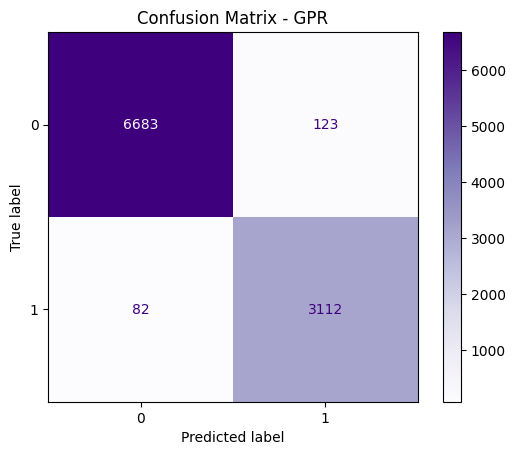

In [30]:
# Extract metrics
results_clean = {k: v for k, v in results.items() if k not in ["Y_pred", "Y_prob"]}

print("\nFinal Test Results:\n")
for k, v in results_clean.items():
    print(f"{k}: {v}")

# Confusion Matrix
test_df = pd.read_csv(test_file)
y_true = test_df["target"]
y_pred = np.array(results["Y_pred"])

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title(f"Confusion Matrix - {results['Model']}")
plt.show()